Optimization Done
Max Sharpe Portfolio: {'GS': 0.3956131305566748, 'BLK': 0.5675531587623112, 'AAPL': 0.0, 'MSFT': 0.019122837720437845, 'AMZN': 0.017710872960576215}
Min Volatility Portfolio: {'GS': 0.1960447684793457, 'BLK': 0.18945332013820806, 'AAPL': 0.2149909837993967, 'MSFT': 0.18314237817895818, 'AMZN': 0.21636854940409123}


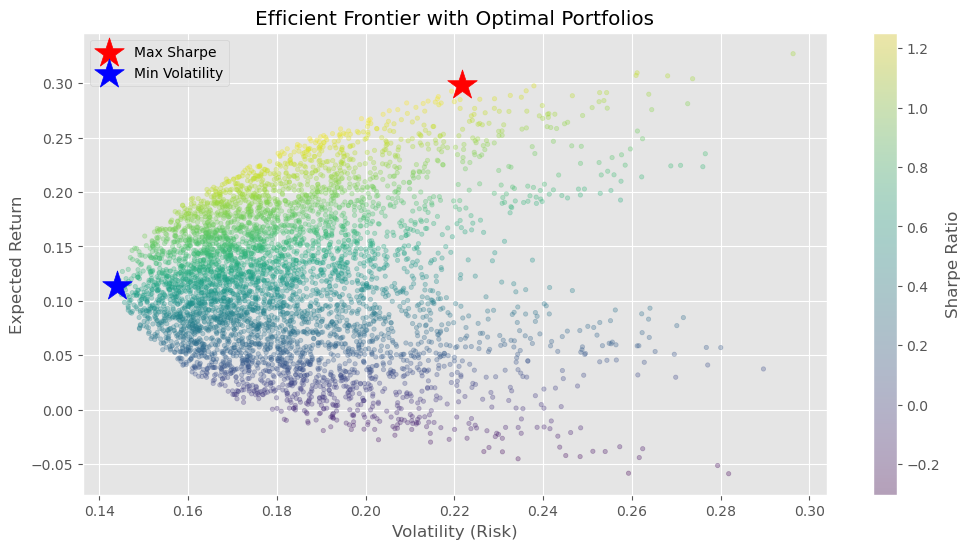

95% Value at Risk (VaR): -0.0229
95% Conditional VaR (CVaR): -0.0291


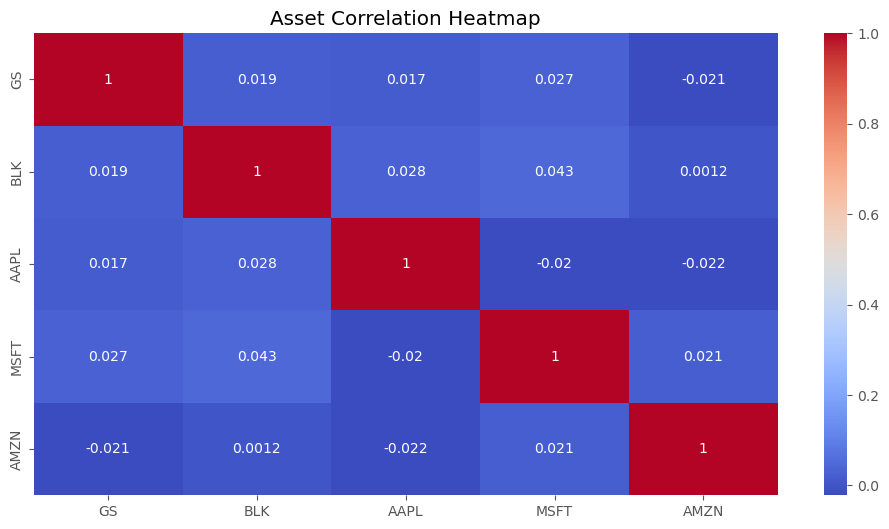

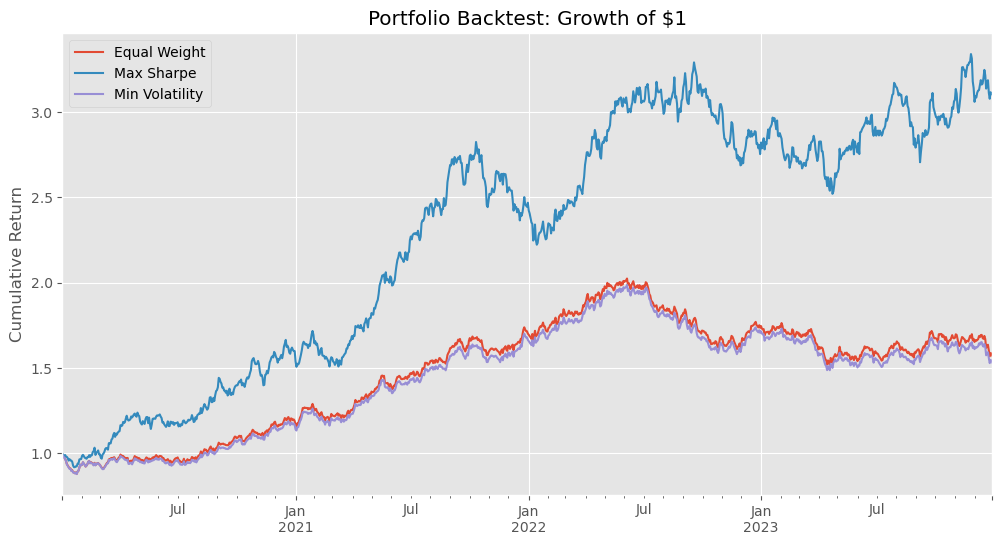

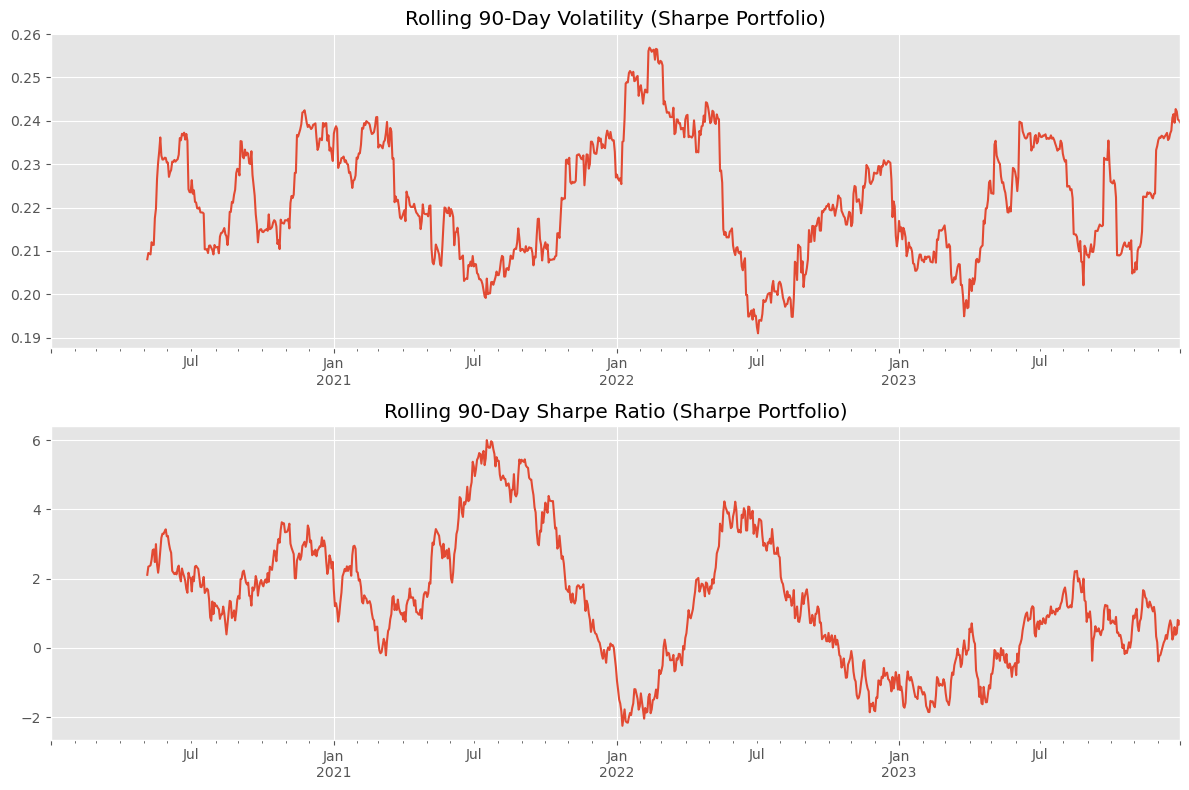

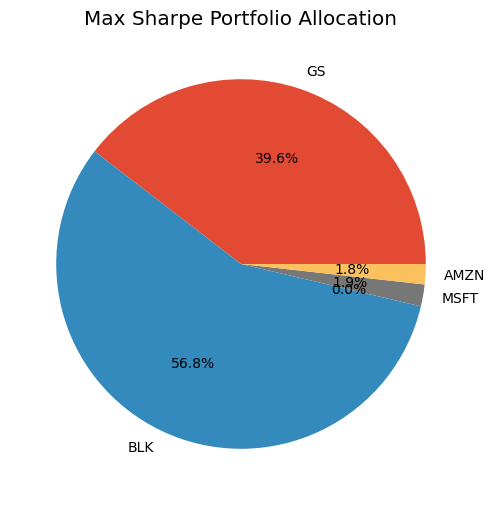


Analysis complete. Results exported to CSV.


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 6)

# ----------------------------
# 1. Load Data
# ----------------------------
data = pd.read_csv("stock_data.csv", index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
mean_returns = returns.mean()
cov_matrix = returns.cov()
RISK_FREE_RATE = 0.02
TICKERS = data.columns.tolist()

# ----------------------------
# 2. Portfolio Performance
# ----------------------------
def portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate=RISK_FREE_RATE):
    weights = np.array(weights)
    annual_return = np.dot(weights, mean_returns) * 252
    annual_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))
    sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility
    return annual_return, annual_volatility, sharpe_ratio

def negative_sharpe(weights): return -portfolio_performance(weights, mean_returns, cov_matrix)[2]
def portfolio_volatility(weights): return portfolio_performance(weights, mean_returns, cov_matrix)[1]

# ----------------------------
# 3. Optimization
# ----------------------------
num_assets = len(TICKERS)
bounds = tuple((0, 1) for _ in range(num_assets))
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
init_guess = num_assets * [1. / num_assets,]

opt_sharpe = minimize(negative_sharpe, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
opt_vol = minimize(portfolio_volatility, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)

opt_sharpe_perf = portfolio_performance(opt_sharpe.x, mean_returns, cov_matrix)
opt_vol_perf = portfolio_performance(opt_vol.x, mean_returns, cov_matrix)

print("Optimization Done")
print("Max Sharpe Portfolio:", dict(zip(TICKERS, opt_sharpe.x)))
print("Min Volatility Portfolio:", dict(zip(TICKERS, opt_vol.x)))

# ----------------------------
# 4. Monte Carlo Simulation
# ----------------------------
n_portfolios = 5000
results = np.zeros((3, n_portfolios))

for i in range(n_portfolios):
    weights = np.random.dirichlet(np.ones(num_assets))
    r, v, s = portfolio_performance(weights, mean_returns, cov_matrix)
    results[0,i], results[1,i], results[2,i] = r, v, s

# ----------------------------
# 5. Efficient Frontier Plot
# ----------------------------
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(opt_sharpe_perf[1], opt_sharpe_perf[0], color='red', marker='*', s=500, label='Max Sharpe')
plt.scatter(opt_vol_perf[1], opt_vol_perf[0], color='blue', marker='*', s=500, label='Min Volatility')
plt.title("Efficient Frontier with Optimal Portfolios")
plt.xlabel("Volatility (Risk)")
plt.ylabel("Expected Return")
plt.legend()
plt.show()

# ----------------------------
# 6. Risk Metrics: VaR & CVaR
# ----------------------------
weights = np.array(opt_sharpe.x)
port_returns = returns.dot(weights)

VaR_95 = np.percentile(port_returns, 5)
CVaR_95 = port_returns[port_returns <= VaR_95].mean()

print(f"95% Value at Risk (VaR): {VaR_95:.4f}")
print(f"95% Conditional VaR (CVaR): {CVaR_95:.4f}")

# ----------------------------
# 7. Correlation Heatmap
# ----------------------------
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm")
plt.title("Asset Correlation Heatmap")
plt.show()

# ----------------------------
# 8. Backtest Portfolios
# ----------------------------
def portfolio_daily_returns(weights, returns):
    return returns.dot(weights)

equal_weights = np.array([1/num_assets] * num_assets)
daily_equal = portfolio_daily_returns(equal_weights, returns)
daily_sharpe = portfolio_daily_returns(opt_sharpe.x, returns)
daily_vol = portfolio_daily_returns(opt_vol.x, returns)

cumulative = pd.DataFrame({
    "Equal Weight": (1 + daily_equal).cumprod(),
    "Max Sharpe": (1 + daily_sharpe).cumprod(),
    "Min Volatility": (1 + daily_vol).cumprod()
}, index=returns.index)

cumulative.plot(title="Portfolio Backtest: Growth of $1")
plt.ylabel("Cumulative Return")
plt.show()

# ----------------------------
# 9. Rolling Risk Metrics
# ----------------------------
rolling_vol = daily_sharpe.rolling(90).std() * np.sqrt(252)
rolling_sharpe = (daily_sharpe.rolling(90).mean() * 252 - RISK_FREE_RATE) / rolling_vol

fig, ax = plt.subplots(2, 1, figsize=(12,8))
rolling_vol.plot(ax=ax[0], title="Rolling 90-Day Volatility (Sharpe Portfolio)")
rolling_sharpe.plot(ax=ax[1], title="Rolling 90-Day Sharpe Ratio (Sharpe Portfolio)")
plt.tight_layout()
plt.show()

# ----------------------------
# 10. Portfolio Allocation Pie Chart
# ----------------------------
pd.Series(opt_sharpe.x, index=TICKERS).plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Max Sharpe Portfolio Allocation")
plt.ylabel("")
plt.show()

# ----------------------------
# 11. Export Results
# ----------------------------
summary = {
    "Max Sharpe Return": opt_sharpe_perf[0],
    "Max Sharpe Volatility": opt_sharpe_perf[1],
    "Max Sharpe Ratio": opt_sharpe_perf[2],
    "Min Vol Return": opt_vol_perf[0],
    "Min Vol Volatility": opt_vol_perf[1],
    "Min Vol Sharpe": opt_vol_perf[2],
    "VaR 95": VaR_95,
    "CVaR 95": CVaR_95
}
pd.DataFrame([summary]).to_csv("portfolio_summary.csv", index=False)
pd.Series(opt_sharpe.x, index=TICKERS).to_csv("optimal_sharpe_weights.csv")
pd.Series(opt_vol.x, index=TICKERS).to_csv("optimal_volatility_weights.csv")

print("\nAnalysis complete. Results exported to CSV.")